<a href="https://colab.research.google.com/github/vadimgb1/heart/blob/main/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Бинарная классификация табличных данных - прогнозирование сердечных заболеваний

## Введение
В этом примере на Colab показано, как настроить и обучить модель нейронной сети для *бинарной классификации*, когда набор данных *табличный* (а не неструктурированные данные, такие как изображения или текст) и содержит сочетание числовых и категориальных признаков. Поскольку табличные наборы данных часто доступны в CSV-файлах, в примере демонстрируется полный рабочий процесс от CSV до обученной модели.




### Данные

Данные ([более подробная информация о данных](https://archive.ics.uci.edu/ml/datasets/heart+Disease)) Содержит информацию о 303 пациентах, по одному в каждой строке. Каждый столбец (т.е. признак) содержит информацию об определенном атрибуте пациента. Столбец с названием «Цель» указывает, был ли у пациента диагностирован сердечный синдром или нет, и является меткой (т.е. зависимой переменной), которую мы хотим предсказать, используя данные из других столбцов.

Описание свойств (скопировано с [here](https://keras.io/examples/structured_data/structured_data_classification_from_scratch/)):

Column| Description| Feature Type
------------|--------------------|----------------------
Age | Возраст в годах | Numerical
Sex | (1 = мужчина; 0 = женщина) | Categorical
CP | Тип боли в груди (0, 1, 2, 3, 4) | Categorical
Trestbpd | Артериальное давление в состоянии покоя (в мм рт. ст. при поступлении) | Numerical
Chol | Уровень холестерина в сыворотке крови (мг/дл) | Numerical
FBS | Уровень сахара в крови натощак 120 мг/дл (1 = true; 0 = false) | Categorical
RestECG | Результаты электрокардиограммы в состоянии покоя (0, 1, 2) | Categorical
Thalach | Достигнута максимальная частота сердечных сокращений | Numerical
Exang | стенокардия, вызванная физической нагрузкой (1 = yes; 0 = no) | Categorical
Oldpeak | Снижение сегмента ST, вызванное физической нагрузкой, по сравнению с состоянием покоя. | Numerical
Slope | Наклон пикового сегмента ST во время физической нагрузки | Numerical
CA | Количество крупных сосудов (0-3), окрашенных при флюороскопии. | Both numerical & categorical
Thal | 3 = normal; 6 = fixed defect; 7 = reversible defect | Categorical
Target | Диагностика заболеваний сердца (1 = true; 0 = false) | Target

## Технические предварительные сведения
В ходе курса мы на первом этапе загрузим следующие пакеты.

In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1773496744.726335   44763 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773496744.731390   44763 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773496747.766166   44763 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773496754.829695   44763 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

При обучении моделей глубокого обучения случайность вступает в процесс в нескольких местах.

* Начальные значения весов (оптимизатор будет пытаться улучшить эти веса)
* Порядок обработки мини-пакетов при использовании SGD
* Разделение данных на обучающую, валидационную, тестовую выборки и т. д.
* Dropout (если используется регуляризация)

Далее мы устанавливаем начальное значение для различных генераторов случайных чисел, чтобы
результаты были одинаковыми при каждом запуске ноутбука. 🤞



In [2]:
keras.utils.set_random_seed(42)

## Загружаем данные

К счастью, набор данных в формате CSV доступен онлайн (автор: [Франсуа Шолле](https://twitter.com/fchollet)) и мы можем загрузить его в Pandas dataframe с помощью очень полезной функции `pd.read_csv`.

In [3]:
df = pd.read_csv("heart.csv")

In [4]:
df.shape

(303, 14)

Набор данных содержит 303 строки и 14 столбцов (13 независимых переменных + 1 зависимая переменная):

Давайте посмотрим на первые несколько строк:

In [5]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0


Давайте быстро проверим, сбалансированы ли единицы и нули.

In [6]:
df.target.value_counts(normalize=True, dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

Модель несколько несбалансирована.

Какая «наивная» **базовая модель** подойдет для решения этой проблемы?

<br> <br> <br> <br>

Базовая модель предполагает прогнозирование вероятности 0,0 для каждого пациента. Это обеспечит точность 72,6%.

Любая сложная модель, которую мы создадим, должна показывать лучшие результаты.

Мы вернемся к этому позже.

## Предварительная обработка

Этот набор данных содержит как категориальные, так и числовые переменные.

Для последующей обработки будет удобно объединить эти группы переменных в два списка.

In [7]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerics = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']

Нейронные сети требуют, чтобы все их входные данные были числовыми, поэтому сначала мы предварительно обработаем эти исходные данные следующим образом:
- *one-hot encoding* категориальных переменных
- *нормализация* числовых переменных

С помощью функции `get_dummies` библиотеки pandas можно выполнить one-hot кодирование в одной строке.

In [8]:

df1 = pd.get_dummies(df, columns = categorical_variables, dtype=int)

In [9]:
df1.head(3)

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,67,160,286,108,1.5,2,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,67,120,229,129,2.6,2,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1


Нейронные сети работают лучше всего, когда все входные данные находятся примерно в одном диапазоне. Поэтому стандартная практика заключается в **стандартизации** числовых переменных.

Прежде чем это сделать, давайте разделим данные на 80% обучающий набор и 20% тестовый набор (*зачем разделять данные **до** нормализации?*).

In [10]:
test_df = df1.sample(frac=0.2, random_state=42)
train_df = df1.drop(test_df.index)

In [11]:
train_df.shape

(242, 30)

In [12]:
test_df.shape

(61, 30)

Хорошо, давайте рассчитаем среднее значение и стандартное отклонение каждой числовой переменной в обучающем наборе данных.

In [13]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()

In [14]:
means

age          54.268595
trestbps    131.995868
chol        246.512397
thalach     149.805785
oldpeak       1.032645
slope         1.590909
dtype: float64

Давайте стандартизируем обучающую и тестовую выборки данных, используя эти средние значения и стандартные отклонения.

In [15]:
train_df[numerics]= (train_df[numerics] - means)/sd
test_df[numerics]= (test_df[numerics] - means)/sd

In [16]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


На данном этапе данные полностью числовые.

Самый простой способ передать данные в Keras/Tensorflow — это использовать массивы NumPy, поэтому мы преобразуем наши два датафрейма в массивы NumPy.

In [17]:
train = train_df.to_numpy()
test = test_df.to_numpy()

Последний шаг: Наши признаки $X$ и зависимая переменная $y$ находятся внутри массивов `train` и `test`, поэтому давайте их разделим.

Обратите внимание, что столбец `target` — это наша переменная $y$, и это шестой столбец слева (считая с 0).

Функция `np.delete` идеально подходит для выбора всех столбцов, кроме одного.

In [18]:
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

Проверьте, всё ли сработало.

In [19]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

Далее выберите только шестой столбец и определите переменные $y$ для обучающей и тестовой выборок.

In [20]:
train_y = train[:, 6]
test_y = test[:, 6]

In [21]:
train_y.shape, test_y.shape

((242,), (61,))

## Создание модели

### Определение модели в Keras

Создание нейронной сети обычно занимает всего несколько строк кода Keras, как мы видели на занятиях.

* Мы начнем с одного скрытого слоя.

* Поскольку это *задача бинарной классификации*, мы будем использовать сигмоидную функцию активации в выходном слое.

Ниже представлена ​​модель, которую мы создали на занятиях.

In [22]:
num_columns = train_X.shape[1]

# define the input layer
input = keras.Input(shape=(num_columns,))

# feed the input vector to the hidden layer
# optional: you can give names to each layer to help
# keep track. This doesn't affect the training etc.

h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)

# feed the output of the hidden layer to the output layer
output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)

# tell Keras that this (input,output) pair is your model
model = keras.Model(input, output)

E0000 00:00:1773496758.070820   44763 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Команда `model.summary()` — это хороший способ быстро получить общее представление о том, что вы определили.

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

Давайте вручную рассчитаем количество параметров, которые необходимо проверить.

In [24]:
(29 + 1)* 16 + (16 + 1) * 1

497

Мы также можем "визуализировать" сеть графически, используя функцию `plot_model` в Keras.

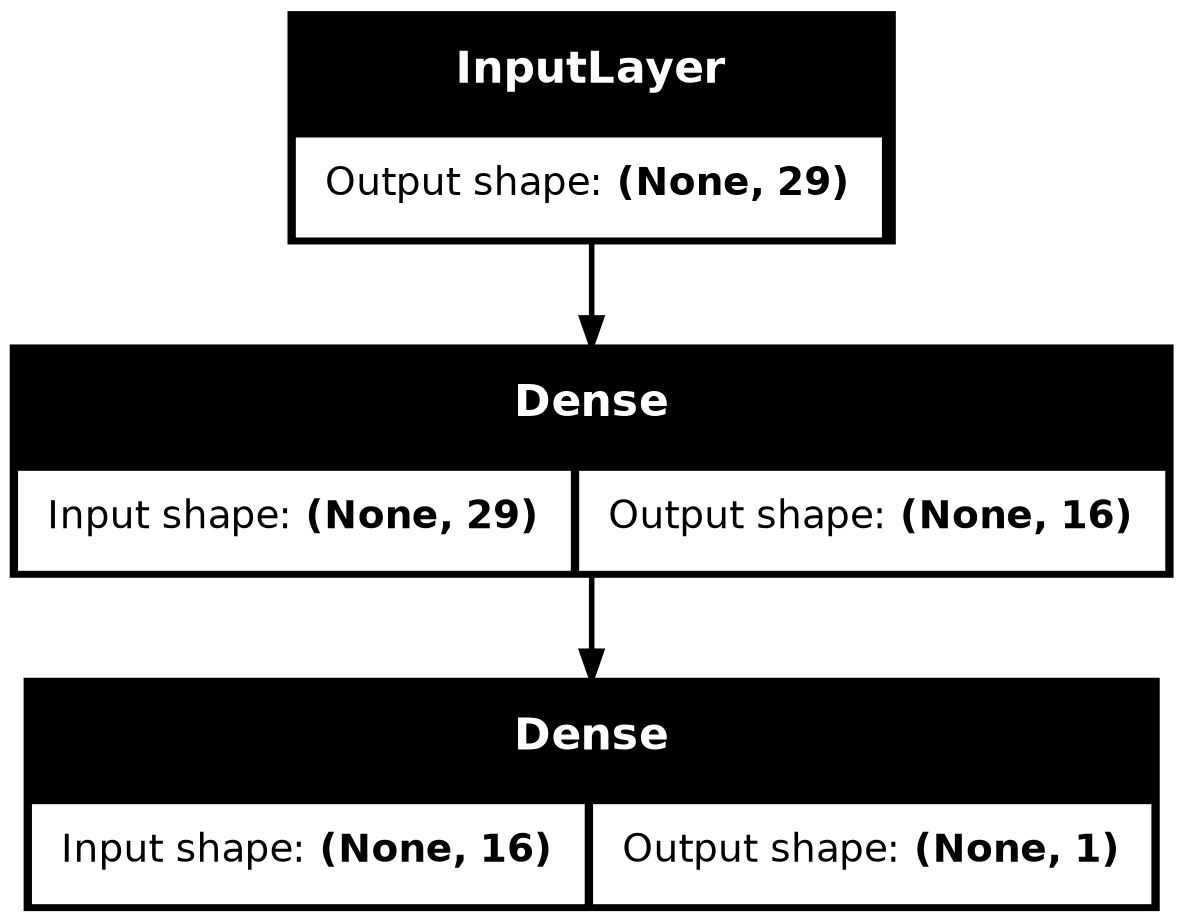

In [25]:

keras.utils.plot_model(model, show_shapes=True)

### Установка параметров оптимизации

Теперь, когда модель определена, нам нужно сообщить Keras три вещи:

* Какую **функцию потерь** использовать — поскольку наша выходная переменная является бинарной, мы выберем функцию потерь `binary_crossentropy`.

* Какой **оптимизатор** использовать — мы будем использовать аналог SGD под названием **Adam**, что является отличным выбором по умолчанию.
* Какие **метрики** вы хотите, чтобы Keras отображал — в задачах классификации, подобных этой, обычно требуется точность.

Эти три параметра можно выбрать с помощью функции `model.fit`.

In [26]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

## Обучение модели

Для начала обучения нам необходимо определиться с тремя вещами:
* *Размер пакета*. На лекции мы называли его *мини-пакетом*, но, следуя общепринятой практике, с этого момента будем просто называть его *пакетом*. 32 — хорошее значение по умолчанию для размера пакета.

* Количество *эпох*, т.е. сколько проходов по обучающим данным. Обычно 20-30 эпох — хорошая отправная точка, но поскольку этот набор данных очень мал, каждая эпоха будет очень быстрой, поэтому давайте запустим обучение на 300 эпох. Это позволит нам увидеть, происходит ли переобучение.
*  Хотим ли мы использовать набор данных для валидации. Это будет полезно для обнаружения переобучения и регуляризации с помощью ранней остановки, поэтому мы попросим Keras автоматически использовать 20% точек данных в качестве набора данных для валидации.

Хорошо, давайте обучим модель, используя функцию `model.fit`!

Мы будем сохранять результаты процесса обучения в `history`. Это позволит легко отслеживать, что происходило во время обучения.

In [27]:
history = model.fit(train_X,              # the array with the input X columns
                    train_y,              # the array with the output y column
                    epochs=300,           # number of epochs to run
                    batch_size=32,        # number of samples (ie data points) per batch
                    verbose=1,            # verbosity during training
                    validation_split=0.2) # use 20% of the data for validation

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5596 - loss: 0.7154 - val_accuracy: 0.5918 - val_loss: 0.6891
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6062 - loss: 0.6826 - val_accuracy: 0.6122 - val_loss: 0.6697
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6321 - loss: 0.6586 - val_accuracy: 0.6122 - val_loss: 0.6530
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6528 - loss: 0.6376 - val_accuracy: 0.6122 - val_loss: 0.6372
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6736 - loss: 0.6181 - val_accuracy: 0.6531 - val_loss: 0.6225
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6995 - loss: 0.5995 - val_accuracy: 0.6939 - val_loss: 0.6088
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7358 - loss: 0.5822 - val_accuracy: 0.6939 - val_loss: 0.5959
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7513 - loss: 0.5658 - val_accuracy: 0.7143 - val_loss: 0.5

Давайте на мгновение задумаемся над представленными цифрами.

---

Построение графиков таких показателей, как потери и точность, в зависимости от количества эпох — хороший способ понять, как продвигалось обучение.

In [28]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

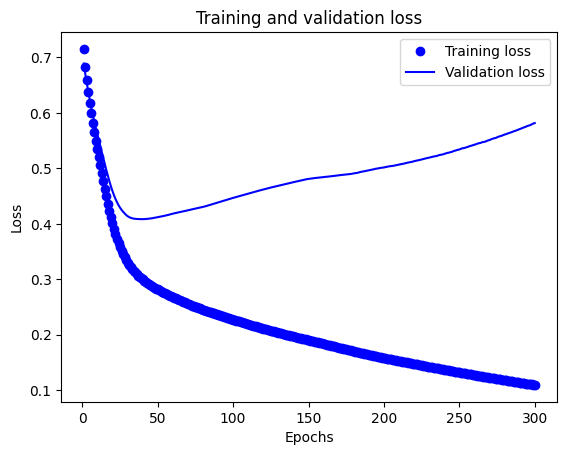

In [29]:
# https://github.com/fchollet/deep-learning-with-python-notebooks/

loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Вы считаете, что происходит переобучение?

<br> <br> <br> <br> <br> <br> <br> <br>

Похоже, что переобучение действительно происходит.

Если переобучение происходит на эпохе N, мы могли бы вернуться назад, переинициализировать модель и просто запустить её на N эпох — это был бы пример **ранней остановки**.

Давайте также посмотрим на кривые точности.

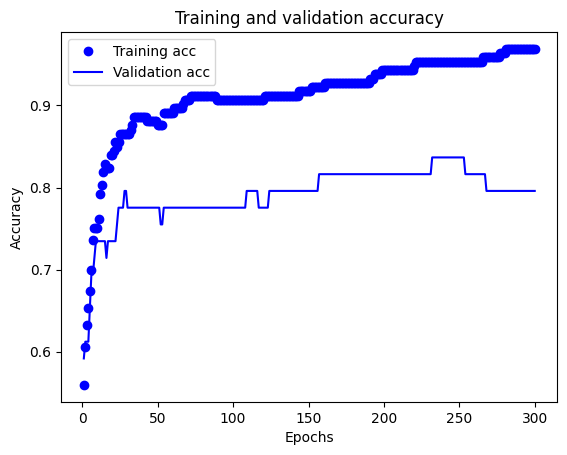

In [30]:
# https://github.com/fchollet/deep-learning-with-python-notebooks/

plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Оценка модели

Давайте посмотрим, **насколько хорошо модель работает на тестовом наборе данных**.

Функция `model.evaluate` очень удобна для расчета производительности вашей модели на любом наборе данных.

In [31]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8361 - loss: 0.4810


[0.4810093939304352, 0.8360655903816223]

Как точность этой «нейронной модели» 😀 соотносится с точностью нашей базовой модели?

Базовая модель показала точность 72,6%, так что наша первая нейронная сеть определенно превосходит её — фух! 😅

## Прогнозирование новых данных (т.е. *вывод*) с помощью модели

В последующих выпусках мы рассмотрим, как сохранить модель Keras и использовать её для прогнозирования. Но мы хотим отметить, что простой подход, который мы использовали в этом выпуске, имеет существенный недостаток.

Мы выполняли предварительную обработку — one-hot кодирование и нормализацию — *вне* модели. Это означает, что нам нужно помнить, какую предварительную обработку мы выполнили, и переносить эту информацию (например, среднее значение и дисперсию каждой переменной) вместе с моделью, чтобы правильно использовать её в будущем.

Очень элегантный способ избежать этой проблемы — использовать [слои предварительной обработки Keras](https://keras.io/guides/preprocessing_layers/). В целях экономии времени мы не будем рассматривать это в данном примере, но рекомендуем вам ознакомиться с этим примером [colab](https://colab.research.google.com/github/keras-team/keras-io/blob/master/examples/structured_data/ipynb/structured_data_classification_from_scratch.ipynb), в котором показано, как решить нашу задачу прогнозирования сердечных заболеваний, используя слои предварительной обработки.